In [21]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn import datasets
from imblearn.over_sampling import SMOTE

In [22]:
# Load dataset
data = datasets.load_iris()
X = data.data
y = data.target

In [23]:
# Convert to DataFrame
df = pd.DataFrame(X, columns=data.feature_names)
df['target'] = y

print("Original Dataset Size:", df.shape)

Original Dataset Size: (150, 5)


In [27]:
#1. Random Sampling

random_sample = df.sample(frac=0.3, random_state=42)
print("Random Sample Size:", random_sample.shape)

Random Sample Size: (45, 5)


In [28]:
#2. Systematic Sampling

step = 3
systematic_sample = df.iloc[::step]
print("Systematic Sample Size:", systematic_sample.shape)

Systematic Sample Size: (50, 5)


In [29]:
# 3. Cluster Sampling

clusters = df.groupby('target')
cluster_sample = clusters.get_group(0)   # selecting cluster 0
print("Cluster Sample Size:", cluster_sample.shape)

Cluster Sample Size: (50, 5)


Original Dataset Size: (150, 5)
Random Sample Size: (45, 5)
Systematic Sample Size: (50, 5)
Cluster Sample Size: (50, 5)
Bootstrap Sample Size: (150, 5)
Before SMOTE: target
0    50
1    50
Name: count, dtype: int64
After SMOTE: target
0    50
1    50
Name: count, dtype: int64


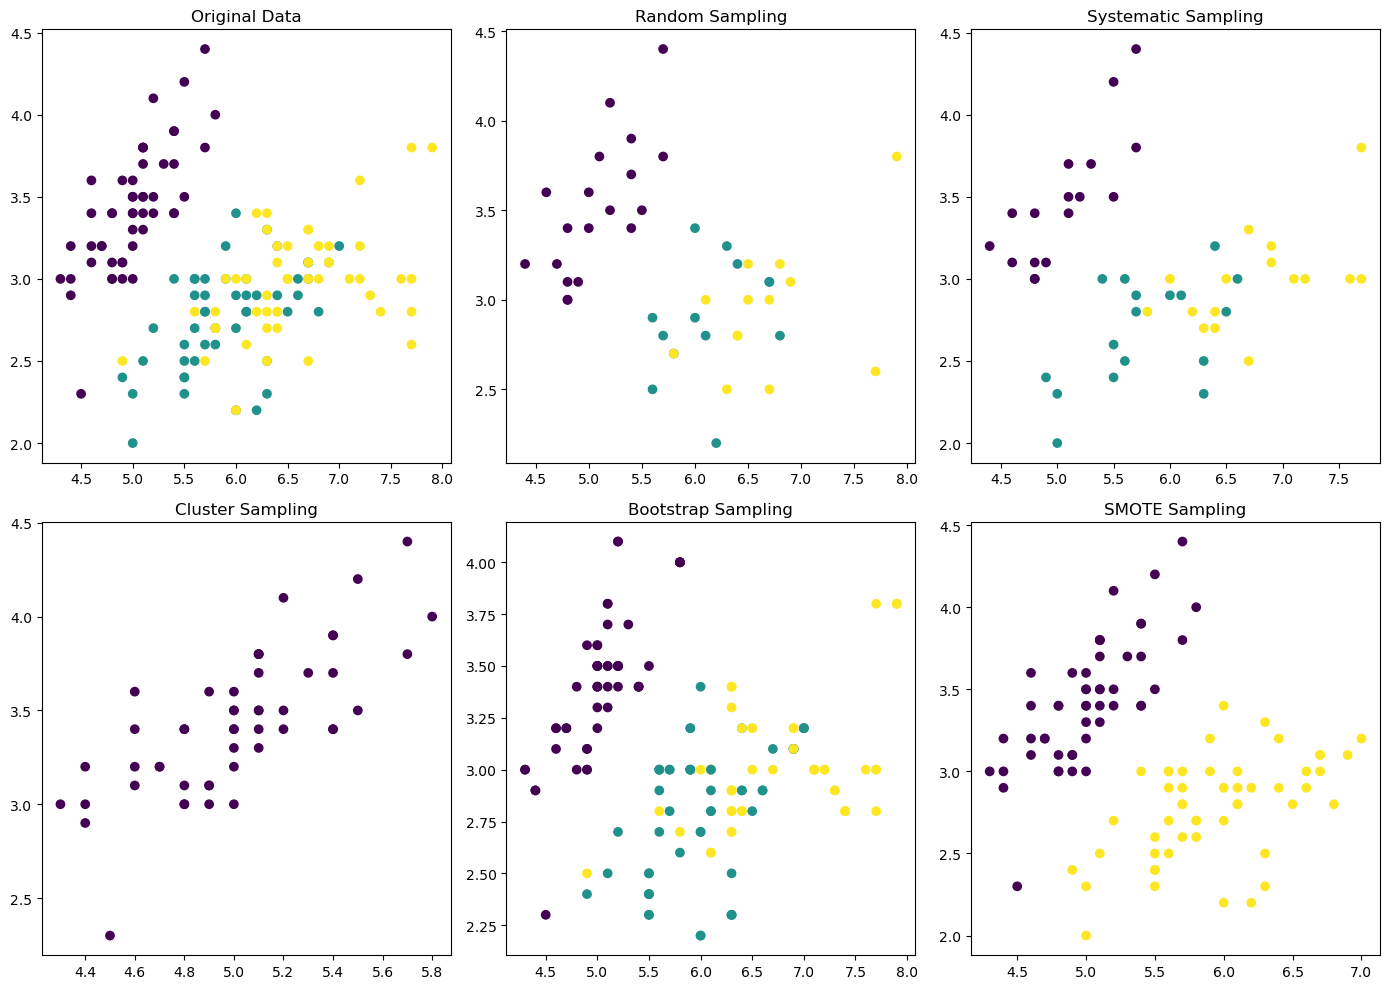

In [20]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn import datasets
from imblearn.over_sampling import SMOTE

# Load dataset
data = datasets.load_iris()
X = data.data
y = data.target

# Convert to DataFrame
df = pd.DataFrame(X, columns=data.feature_names)
df['target'] = y

print("Original Dataset Size:", df.shape)

# ---------------------------------
# 1. Random Sampling
# ---------------------------------
random_sample = df.sample(frac=0.3, random_state=42)
print("Random Sample Size:", random_sample.shape)

# ---------------------------------
# 2. Systematic Sampling
# ---------------------------------
step = 3
systematic_sample = df.iloc[::step]
print("Systematic Sample Size:", systematic_sample.shape)

# ---------------------------------
# 3. Cluster Sampling
# ---------------------------------
clusters = df.groupby('target')
cluster_sample = clusters.get_group(0)   # selecting cluster 0
print("Cluster Sample Size:", cluster_sample.shape)

# ---------------------------------
# 4. Bootstrap Sampling
# ---------------------------------
bootstrap_sample = df.sample(n=len(df), replace=True, random_state=42)
print("Bootstrap Sample Size:", bootstrap_sample.shape)

# ---------------------------------
# 5. SMOTE Sampling (for imbalanced data)
# ---------------------------------
# Artificially make data imbalanced
df_imbalanced = df[df['target'] != 2]

X_imb = df_imbalanced.drop('target', axis=1)
y_imb = df_imbalanced['target']

smote = SMOTE(random_state=42)
X_smote, y_smote = smote.fit_resample(X_imb, y_imb)

print("Before SMOTE:", y_imb.value_counts())
print("After SMOTE:", pd.Series(y_smote).value_counts())

# ---------------------------------
# Visualization
# ---------------------------------
plt.figure(figsize=(14,10))

# Original
plt.subplot(2,3,1)
plt.scatter(X[:,0], X[:,1], c=y)
plt.title("Original Data")

# Random
plt.subplot(2,3,2)
plt.scatter(random_sample.iloc[:,0], random_sample.iloc[:,1],
            c=random_sample['target'])
plt.title("Random Sampling")

# Systematic
plt.subplot(2,3,3)
plt.scatter(systematic_sample.iloc[:,0], systematic_sample.iloc[:,1],
            c=systematic_sample['target'])
plt.title("Systematic Sampling")

# Cluster
plt.subplot(2,3,4)
plt.scatter(cluster_sample.iloc[:,0], cluster_sample.iloc[:,1],
            c=cluster_sample['target'])
plt.title("Cluster Sampling")

# Bootstrap
plt.subplot(2,3,5)
plt.scatter(bootstrap_sample.iloc[:,0], bootstrap_sample.iloc[:,1],
            c=bootstrap_sample['target'])
plt.title("Bootstrap Sampling")

# SMOTE
plt.subplot(2,3,6)
plt.scatter(X_smote.iloc[:,0], X_smote.iloc[:,1], c=y_smote)
plt.title("SMOTE Sampling")

plt.tight_layout()
plt.show()